## Plot ACCESS-EMS-GBR coupled fields

Currently only coupled through SST and heat fluxes.

Uses xp65 analysis3-25.08 environment

In [1]:
import iris
import iris.analysis
import xarray as xr
from xarray.coding.times import CFTimedeltaCoder
import datetime as dt
import numpy as np
import pandas as pd
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import cmocean
import cartopy as cp
import cartopy.crs as ccrs
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter, RRuleLocator, rrulewrapper
from dateutil.rrule import rrule, DAILY
import matplotlib.gridspec as gridspec
import xesmf as xe

### Plot settings

In [2]:
fig_dir = 'plots/'
fontsize = 14
plt.rcParams.update({'font.size':fontsize, 'mathtext.default':'regular'})
date_form = DateFormatter("%d-%m-%y")
plt_labels = ['A','B','C','D']

### Sample sea surface temperature ancillary data (Feb 2022)

Ancillary data used to force the NE AUS domain for February 2022, demonstrating improved representation of SST variability (eg. elevated SST in the lead up to the 2022 mass coral bleaching event) when using daily BRAN2020 source data and coupling to EMS.

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/common/mixin.py:203: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/coords.py:2172: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/coords.py:2172: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: I

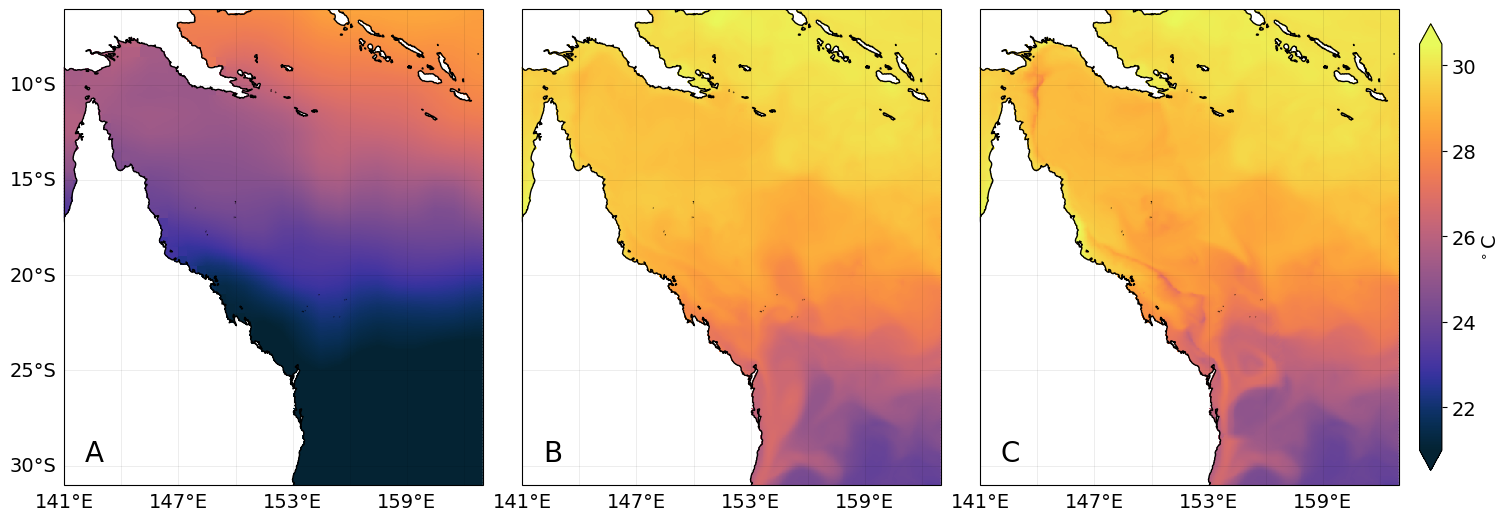

In [3]:
# Load ancillary data
start_dt = dt.datetime(2022,2,1)
end_dt = dt.datetime(2022,2,28)
constrain_month = iris.Constraint(time = lambda cell: start_dt.month <= cell.point.month <= end_dt.month)
constrain_day = iris.Constraint(time = lambda cell: start_dt <= cell.point <= end_dt)
sst_hadisst = iris.load_cube('~/UM_NS/ancils/NE_Aus/4km/qrclim.sst.hadisst').extract(constrain_month)  # HADISST monthly mean
sst_accessgbr = iris.load_cube('~/UM_NS/ancils/NE_Aus/4km/qrclim.sst.bran2020').extract(constrain_day) # BRAN2020 daily mean
sst_accessemsgbr = iris.load_cube('~/UM_NS/output/RRAP/ACCESS-EMS-GBR/u-dn070/ancils_2022/NE_Aus_4km/qrclim.sst.bran2020.ereefs').extract(constrain_day) # Merged BRAN2020-GBR4 daily mean

# Format data for plotting
sst_accessgbr = sst_accessgbr.collapsed('time',iris.analysis.MEAN)
sst_accessemsgbr = sst_accessemsgbr.collapsed('time',iris.analysis.MEAN)

# Set up maps
cNorm = colors.Normalize(vmin=21, vmax=30.5)
cmap = cmocean.cm.thermal
nrows = 1
ncols = 3
plt_height=10
plt_width=15
im_ratio = plt_height/plt_width
fig, axs = plt.subplots(nrows, ncols, figsize=(plt_width,plt_height), subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

# Plot time-average
ax0 = axs[0].pcolor(sst_hadisst.coord('longitude').points, sst_hadisst.coord('latitude').points, sst_hadisst.data - 273.15, transform=ccrs.PlateCarree(), norm=cNorm, cmap=cmap)
ax1 = axs[1].pcolor(sst_accessgbr.coord('longitude').points, sst_accessgbr.coord('latitude').points, sst_accessgbr.data - 273.15, transform=ccrs.PlateCarree(), norm=cNorm, cmap=cmap)
ax2 = axs[2].pcolor(sst_accessemsgbr.coord('longitude').points, sst_accessemsgbr.coord('latitude').points, sst_accessemsgbr.data - 273.15, transform=ccrs.PlateCarree(), norm=cNorm, cmap=cmap)

# Add map features
fig.colorbar(ax2, fraction=0.08*im_ratio, orientation='vertical', extend='both').set_label(label='$^\circ$C', size=fontsize)
for iplt in range(nrows*ncols):
    axs[iplt].coastlines('10m')
    gl = axs[iplt].gridlines(crs=ccrs.PlateCarree(),draw_labels=True,color='black',linewidth=0.5,alpha=0.1)
    gl.top_labels = False
    gl.right_labels = False
    if iplt != 0:
        gl.left_labels = False
    axs[iplt].annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.05,0.05), fontsize=20, color='k')

plt.savefig(fig_dir+'Fig02.png', bbox_inches='tight', dpi=300)

### Surface net heat fluxes (February 2022)

Air-sea heat fluxes = positive  
Sea-air heat fluxes = negative

In [4]:
suite = 'dn070'
rgn = 'NE_Aus'
res = '4km'
fcst = 48
start_dt = dt.datetime(2022,2,1)
end_dt = dt.datetime(2022,2,28)
out_dir = '~/UM_NS/output/RRAP/ACCESS-EMS-GBR/u-dn070/'

# Read UM model output
atmos_ds = xr.open_mfdataset(out_dir + 'um2nc/'+suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-2022*', concat_dim='time', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True)).sel(time=slice(start_dt,end_dt))
atmos_ds = atmos_ds.isel(model_level_number=0)
atmos_ds['NHF'] = atmos_ds['m01s01i202'] + atmos_ds['m01s02i201'] + -atmos_ds['m01s03i217'] + -atmos_ds['m01s03i234'] # SWR+LWR+SHF+LHF

# Read EMS model output
hydro_ds = xr.open_mfdataset(out_dir + 'gbr4_hydro/gbr4_surf_2022*', concat_dim='record', combine='nested', data_vars='different', decode_timedelta=CFTimedeltaCoder(decode_via_units=True)).isel(k_centre=0)
hydro_ds = hydro_ds.swap_dims({'record':'t'})
hydro_ds = hydro_ds.assign_coords(t = pd.to_datetime(hydro_ds.t).round('h'))
hydro_ds = hydro_ds.rename({'t':'time'})
hydro_ds = hydro_ds.sel(time=slice(start_dt,end_dt))
hydro_ds['NHF'] = hydro_ds['swr'] + hydro_ds['lwr'] + hydro_ds['shf'] + hydro_ds['lhf']

# Regrid eReefs output to atmos grid for comparison
hydro_ds = hydro_ds.transpose('time', 'i_centre', 'j_centre', ...)
hydro_ds = hydro_ds.rename_vars({'y_centre':'latitude', 'x_centre':'longitude'})
hydro_ds = hydro_ds.reset_coords('latitude')
src_grid = xr.merge([hydro_ds.longitude,hydro_ds.latitude])
tgt_grid = xr.Dataset({'latitude' : (['latitude'], atmos_ds.latitude.values), 'longitude' : (['longitude'], atmos_ds.longitude.values)})
regridder = xe.Regridder(src_grid, tgt_grid, 'bilinear', unmapped_to_nan=True)
nhf_ocean = regridder(hydro_ds['NHF'].copy())
    
# Format data for plotting
nhf_ocean_2d = nhf_ocean.copy().mean(dim='time', skipna=True, keep_attrs=True)
nhf_ocean_ts = nhf_ocean.copy().mean(dim=['latitude','longitude'], skipna=True, keep_attrs=True)
gbr4_mask = xr.where(np.isfinite(nhf_ocean_2d), 1, 0)
nhf_atmos = xr.where(gbr4_mask==1, atmos_ds['NHF'], np.nan)
nhf_atmos_2d = nhf_atmos.copy().mean(dim='time', skipna=True, keep_attrs=True)
nhf_atmos_ts = nhf_atmos.copy().mean(dim=['latitude','longitude'], skipna=True, keep_attrs=True)

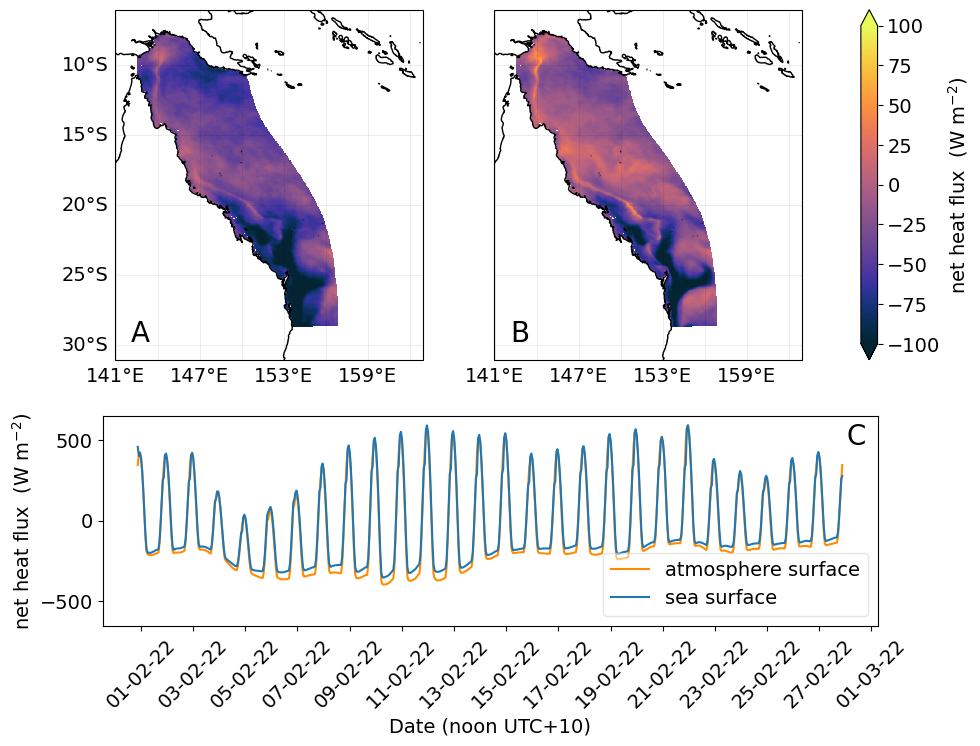

In [5]:
# Set up plot
cmap = cmocean.cm.thermal
dmap = cmocean.cm.balance
cNorm = colors.Normalize(vmin=-100, vmax=100)
dNorm = colors.TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)
plt_height=8
plt_width=10
map_ratio = plt_height/plt_width
fig = plt.figure(figsize=(plt_width,plt_height))
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[1,1,0.05], height_ratios=[1,0.6])

# Plot time-average maps
for iplt in range(2):
    iax = fig.add_subplot(gs[0,iplt], projection=ccrs.PlateCarree())
    if iplt == 0:
        imap = iax.pcolormesh(nhf_atmos_2d.longitude, nhf_atmos_2d.latitude, nhf_atmos_2d, cmap=cmap, norm=cNorm)
    elif iplt == 1:
        imap = iax.pcolormesh(nhf_ocean_2d.longitude, nhf_ocean_2d.latitude, nhf_ocean_2d, cmap=cmap, norm=cNorm)
        fig.colorbar(imap, cax=plt.subplot(gs[0,iplt+1]), orientation='vertical', extend='both').set_label(label='net heat flux  (W m$^{-2}$)')
    
    # Add map features
    iax.annotate(plt_labels[iplt], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.05,0.05), fontsize=20, color='black')
    iax.coastlines('10m')
    gl = iax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,color='black',linewidth=0.5,alpha=0.1)
    gl.top_labels = False
    gl.right_labels = False 
    if iplt == 1:
        gl.left_labels = False

# Plot area mean time-series (GBR4 domain)
ax_ts = fig.add_subplot(gs[1,:])
ax_ts.plot(nhf_atmos_ts.time, nhf_atmos_ts, color='darkorange')
ax_ts.plot(nhf_ocean_ts.time, nhf_ocean_ts, color='C0')
ax_ts.legend(['atmosphere surface','sea surface'], loc='lower right', framealpha=0.5)
ax_ts.annotate(plt_labels[iplt+1], xy=(0.1,0.1), xycoords='axes fraction', xytext=(0.96,0.86), fontsize=20, color='black')
ax_ts.set(xlabel = 'Date (noon UTC+10)', ylabel='net heat flux  (W m$^{-2}$)')
ax_ts.xaxis.set_major_formatter(date_form)
start_dt = dt.datetime(atmos_ds.time[0].dt.year.values, atmos_ds.time[0].dt.month.values, atmos_ds.time[0].dt.day.values, 2)
xtick_rule = rrulewrapper(freq=DAILY, interval=2, byhour=2, dtstart=start_dt)
xtick_loc = RRuleLocator(xtick_rule)
ax_ts.xaxis.set_major_locator(xtick_loc)
ax_ts.tick_params('x', labelrotation=45)
ax_ts.set_ylim([-650, 650])

plt.savefig(fig_dir+'FigA1.png', bbox_inches='tight', dpi=300)